In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

import warnings
warnings.filterwarnings('ignore')

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
# Load the data
df = pd.read_csv('titanic.csv')

print("Dataset shape:", df.shape)
df.head()

Dataset shape: (891, 12)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [3]:
# Check for missing values
missing_values = df.isnull().sum()
missing_percent = (missing_values / len(df)) * 100
missing_df = pd.DataFrame({'Missing Values': missing_values, 'Percent': missing_percent})
missing_df[missing_df['Missing Values'] > 0]

,Missing Values,Percent
Age,177,19.865320
Cabin,687,77.104377
Embarked,2,0.224467


In [4]:
# Create a clean copy
df_clean = df.copy()

# 1. Handle Age: Impute with median by Pclass and Sex
df_clean['Age'] = df_clean.groupby(['Pclass', 'Sex'])['Age'].transform(
    lambda x: x.fillna(x.median())
)

# 2. Handle Cabin: Extract deck and create has_cabin flag
df_clean['Deck'] = df_clean['Cabin'].str[0]
df_clean['Has_Cabin'] = df_clean['Cabin'].notna().astype(int)

# 3. Handle Embarked: Fill with mode
df_clean['Embarked'] = df_clean['Embarked'].fillna(df_clean['Embarked'].mode()[0])

# 4. Create Family Size feature
df_clean['Family_Size'] = df_clean['SibSp'] + df_clean['Parch']
df_clean['Is_Alone'] = (df_clean['Family_Size'] == 0).astype(int)

# 5. Extract Title from Name
df_clean['Title'] = df_clean['Name'].str.extract(r' ([A-Za-z]+)\.', expand=False)

print("Missing values after cleaning:")
print(df_clean.isnull().sum())

Missing values after cleaning:
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age              0
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         0
Deck           687
Has_Cabin        0
Family_Size      0
Is_Alone         0
Title            0
dtype: int64


Overall Survival Rate: 38.4%


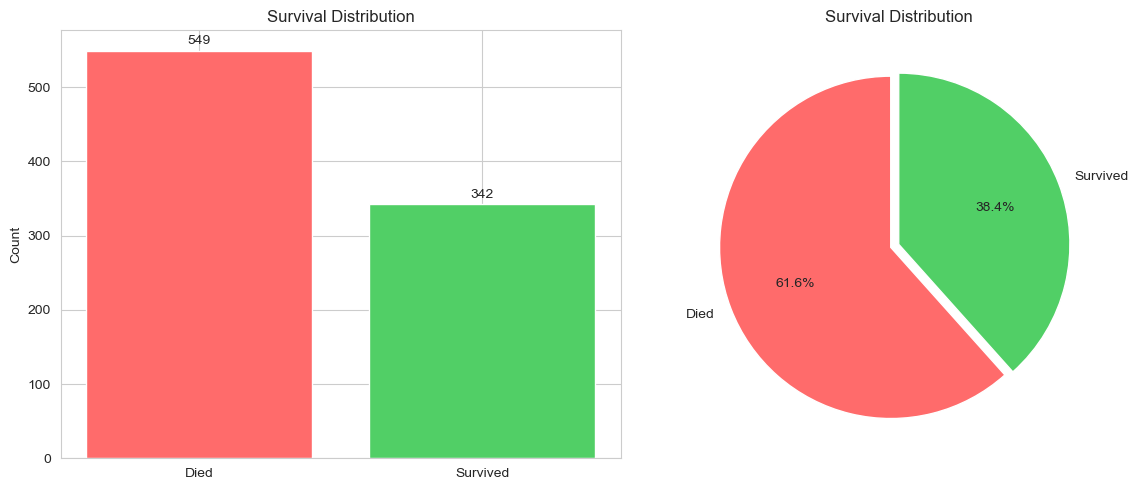

In [5]:
# Overall survival statistics
survival_rate = df_clean['Survived'].mean() * 100
print(f"Overall Survival Rate: {survival_rate:.1f}%")

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Bar plot
survival_counts = df_clean['Survived'].value_counts()
axes[0].bar(['Died', 'Survived'], survival_counts, color=['#ff6b6b', '#51cf66'])
axes[0].set_title('Survival Distribution')
axes[0].set_ylabel('Count')
for i, v in enumerate(survival_counts):
    axes[0].text(i, v + 5, str(v), ha='center', va='bottom')

# Pie chart
axes[1].pie(survival_counts, labels=['Died', 'Survived'], 
            autopct='%1.1f%%', colors=['#ff6b6b', '#51cf66'],
            startangle=90, explode=(0.05, 0))
axes[1].set_title('Survival Distribution')

plt.tight_layout()
plt.show()

Survival by Sex:
        count  Survival Rate
Sex                         
female    314           74.2
male      577           18.9


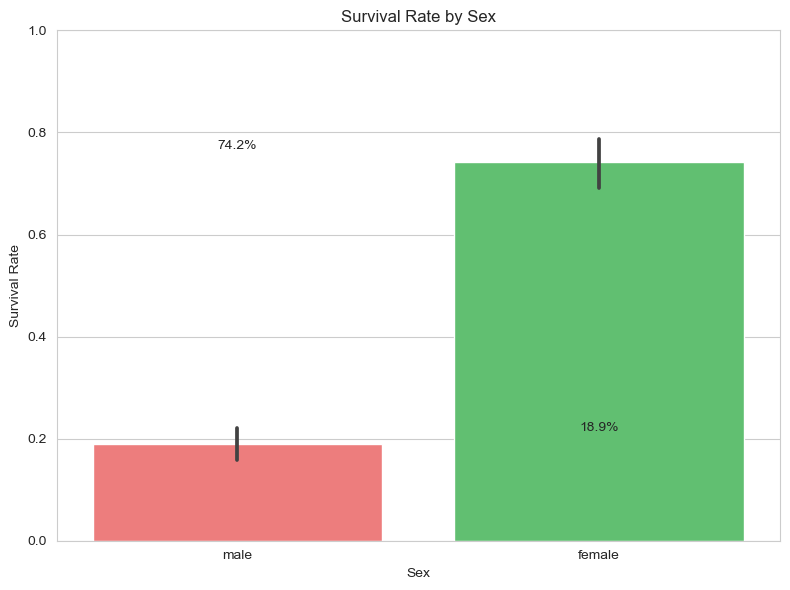

In [6]:
# Survival by Sex
sex_survival = df_clean.groupby('Sex')['Survived'].agg(['mean', 'count']).round(3)
sex_survival['Survival Rate'] = (sex_survival['mean'] * 100).round(1)
print("Survival by Sex:")
print(sex_survival[['count', 'Survival Rate']])

fig, ax = plt.subplots(figsize=(8, 6))
sns.barplot(data=df_clean, x='Sex', y='Survived', 
            palette=['#ff6b6b', '#51cf66'], ax=ax)
ax.set_title('Survival Rate by Sex')
ax.set_ylabel('Survival Rate')
ax.set_ylim(0, 1)

for i, v in enumerate(df_clean.groupby('Sex')['Survived'].mean()):
    ax.text(i, v + 0.02, f'{v*100:.1f}%', ha='center', va='bottom')

plt.tight_layout()
plt.show()

Survival by Passenger Class:
        count  Survival Rate
Pclass                      
1         216           63.0
2         184           47.3
3         491           24.2


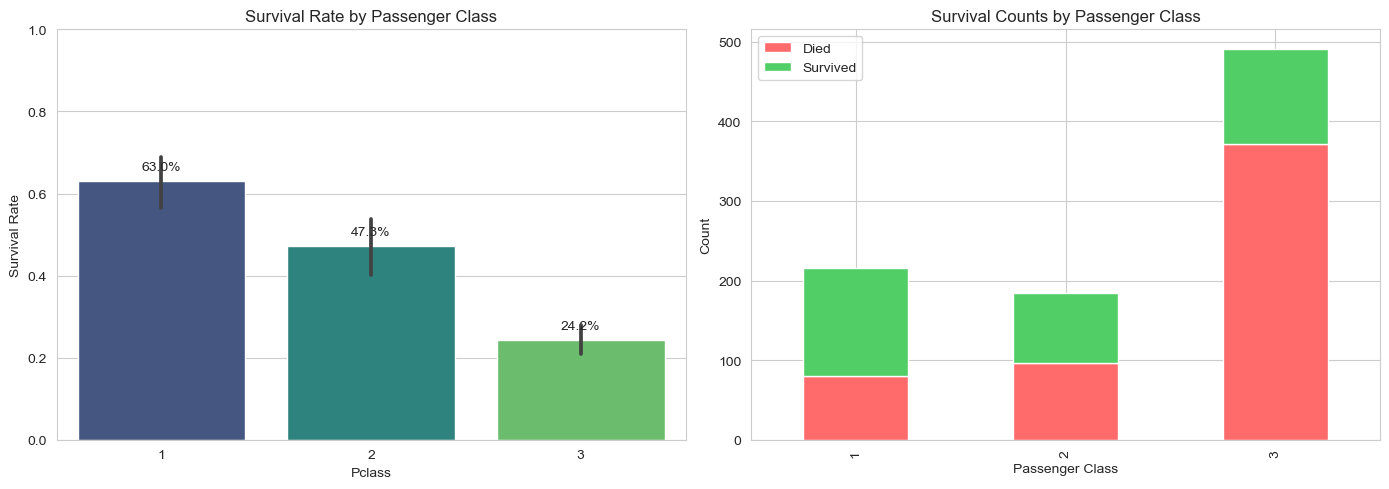

In [7]:
# Survival by Pclass
class_survival = df_clean.groupby('Pclass')['Survived'].agg(['mean', 'count']).round(3)
class_survival['Survival Rate'] = (class_survival['mean'] * 100).round(1)
print("Survival by Passenger Class:")
print(class_survival[['count', 'Survival Rate']])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.barplot(data=df_clean, x='Pclass', y='Survived',
            palette='viridis', ax=axes[0])
axes[0].set_title('Survival Rate by Passenger Class')
axes[0].set_ylabel('Survival Rate')
axes[0].set_ylim(0, 1)

for i, v in enumerate(df_clean.groupby('Pclass')['Survived'].mean()):
    axes[0].text(i, v + 0.02, f'{v*100:.1f}%', ha='center', va='bottom')

class_survival_counts = pd.crosstab(df_clean['Pclass'], df_clean['Survived'])
class_survival_counts.plot(kind='bar', stacked=True, color=['#ff6b6b', '#51cf66'], 
                           ax=axes[1])
axes[1].set_title('Survival Counts by Passenger Class')
axes[1].set_xlabel('Passenger Class')
axes[1].set_ylabel('Count')
axes[1].legend(['Died', 'Survived'])

plt.tight_layout()
plt.show()

Survival by Age Group (%):
Age_Group
0-10     59.4
11-20    38.3
21-30    32.4
31-40    44.9
41-50    38.4
51-60    40.5
60+      22.7
Name: Survived, dtype: float64


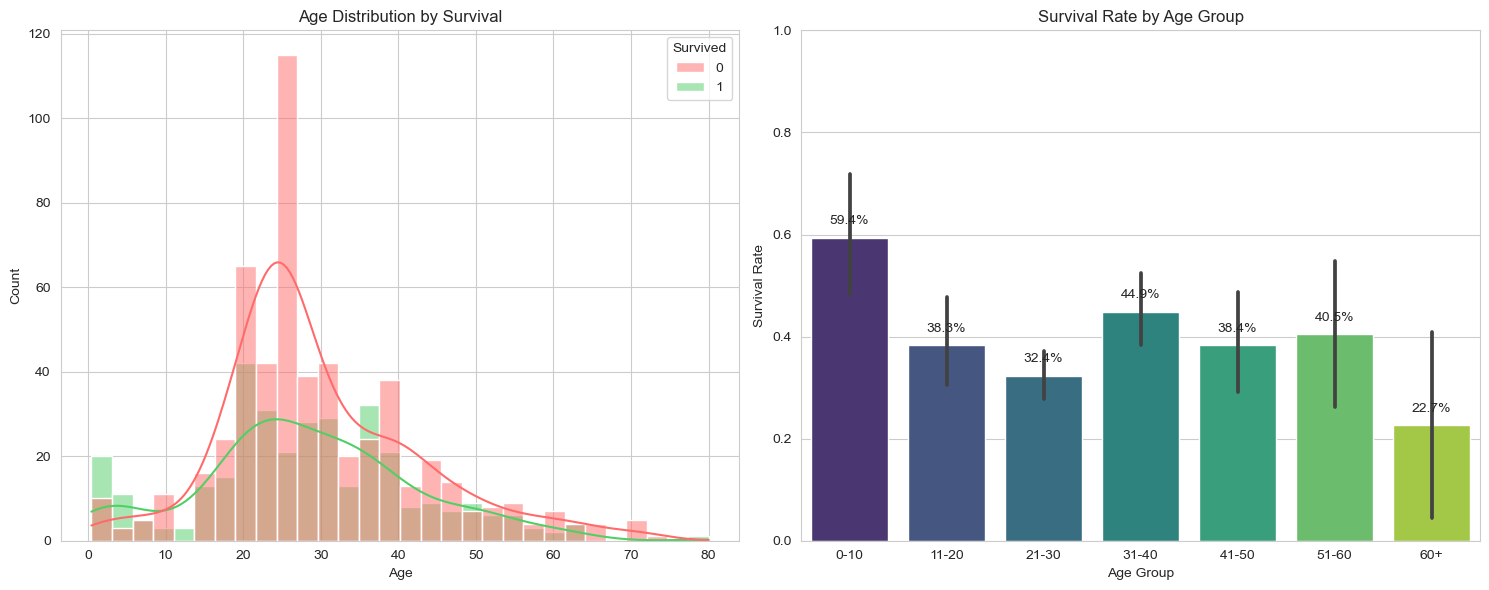

In [8]:
bins = [0, 10, 20, 30, 40, 50, 60, 100]
labels = ['0-10', '11-20', '21-30', '31-40', '41-50', '51-60', '60+']
df_clean['Age_Group'] = pd.cut(df_clean['Age'], bins=bins, labels=labels)

age_survival = df_clean.groupby('Age_Group')['Survived'].mean().round(3) * 100
print("Survival by Age Group (%):")
print(age_survival)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

sns.histplot(data=df_clean, x='Age', hue='Survived', bins=30,
             kde=True, palette=['#ff6b6b', '#51cf66'], ax=axes[0])
axes[0].set_title('Age Distribution by Survival')
axes[0].set_xlabel('Age')
axes[0].set_ylabel('Count')

sns.barplot(x='Age_Group', y='Survived', data=df_clean,
            palette='viridis', ax=axes[1])
axes[1].set_title('Survival Rate by Age Group')
axes[1].set_ylabel('Survival Rate')
axes[1].set_xlabel('Age Group')
axes[1].set_ylim(0, 1)

for i, v in enumerate(age_survival):
    axes[1].text(i, v/100 + 0.02, f'{v:.1f}%', ha='center', va='bottom')

plt.tight_layout()
plt.show()

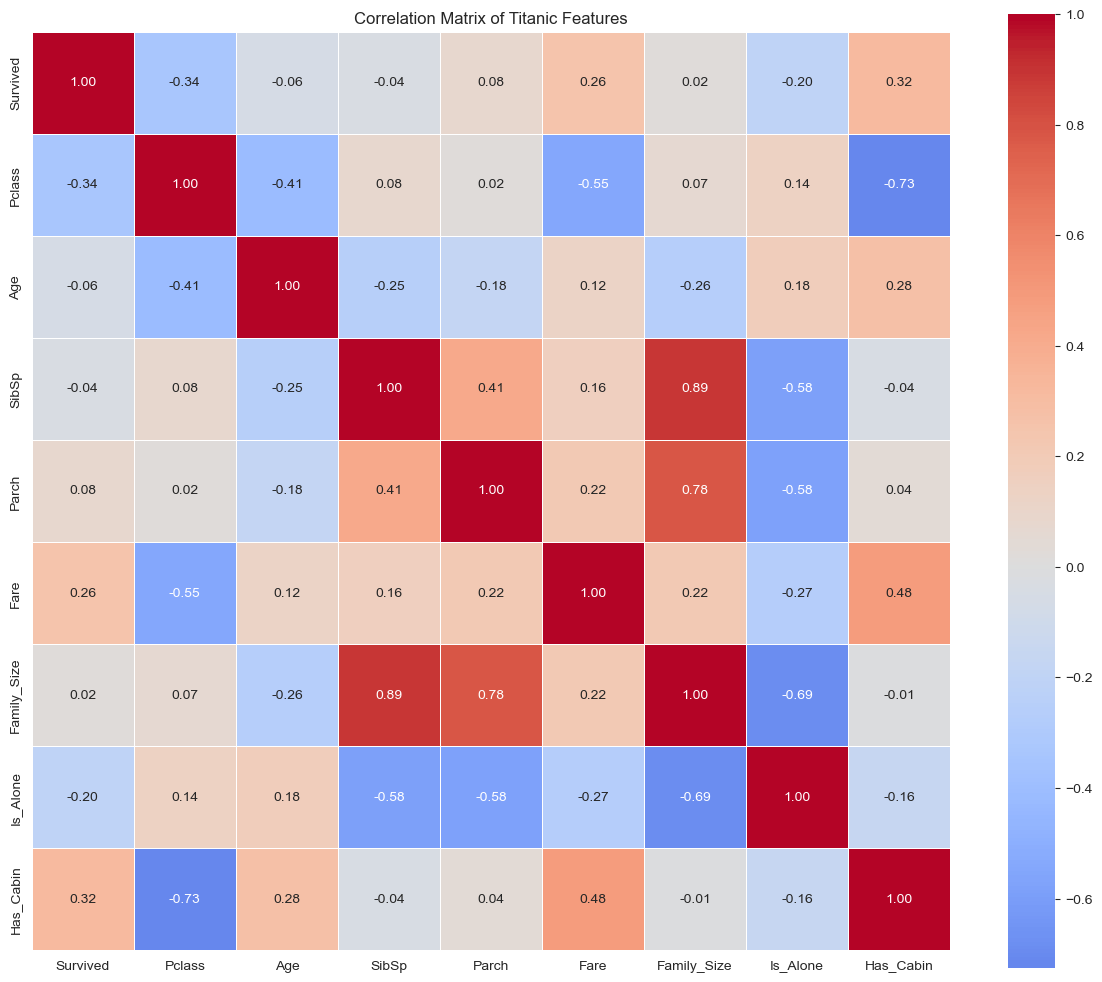


Correlations with Survival:
Has_Cabin: 0.317
Fare: 0.257
Parch: 0.082
Family_Size: 0.017
SibSp: -0.035
Age: -0.060
Is_Alone: -0.203
Pclass: -0.338


In [9]:
numeric_features = ['Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 
                   'Fare', 'Family_Size', 'Is_Alone', 'Has_Cabin']

corr_matrix = df_clean[numeric_features].corr()

fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0,
            linewidths=0.5, fmt='.2f', square=True, ax=ax)
ax.set_title('Correlation Matrix of Titanic Features')
plt.tight_layout()
plt.show()

survival_corr = corr_matrix['Survived'].sort_values(ascending=False)
print("\nCorrelations with Survival:")
for feature, corr in survival_corr.items():
    if feature != 'Survived':
        print(f"{feature}: {corr:.3f}")